# EEG_05 — Braindecode Baseline su Segnale Raw (4/5 Classi Semantiche)

Questo notebook testa **6 modelli end-to-end** di [Braindecode](https://braindecode.org) sul segnale EEG grezzo,
usando il clustering semantico a 4 e 5 classi invece delle 110 parole originali.

**Richiede**: ambiente `daniele_311` (Python 3.11) per Labram.

## Modelli testati
| Modello | Architettura | Parametri | Note |
|---------|-------------|-----------|------|
| **EEGNet** | CNN compatta | ~2.8K | Baseline leggero, universale |
| **ShallowFBCSPNet** | CNN freq-domain | ~98K | Ispira a FBCSP classico |
| **Deep4Net** | CNN profonda | ~261K | Baseline convoluzionale solido |
| **EEGConformer** | CNN + Transformer | ~429K | Pattern locali e globali |
| **ATCNet** | Attention + TCN | ~44K | Sliding window con attenzione |
| **Labram** | Criss-Cross Transformer | ~5M | Foundation model per EEG, richiede Python 3.11 |

## Setup dati
- Input: segnale EEG grezzo `(batch, 59, 384)` — 59 canali × 384 campioni a 256 Hz (~1.5s)
- Labram: input paddato a `(batch, 59, 400)` per compatibilità con `patch_size=200`
- Label: cluster semantici a **4 classi** (azioni, cognitivo, emozioni, oggetti) o **5 classi**
- Valutazione: **subject-independent** (train:01-50, val:51-60, test:61-74)

Data: 2026-03-12

In [ ]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True         # False → 110 parole originali
CLUSTER_SCHEME = "concr4"    # Schemi word-based (affidabili, da usare per training):
#                              "concr4" | "phon4" | "sem5" | "pos4" | "ward5" | "ward4" | "ward6"
#                              Schemi EEG-based (ARI≈0 cross-subject, solo analisi):
#                              "eeg_4" | "eeg_5" | "eeg_z4" | "eeg_z5"
#                              (ignorato se USE_CLUSTERS = False)
# ═══════════════════════════════════════════════════════════

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
import h5py
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from braindecode.models import EEGNet, EEGConformer, Deep4Net, ShallowFBCSPNet, ATCNet, Labram

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import braindecode; print("braindecode:", braindecode.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
braindecode: 1.3.2

In [3]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV   = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH  = project_root / "src" / "io" / "ebneuro.locs"

# Parametri EEG
N_CHANS         = 61    # canali dopo rimozione A1, A2
N_TIMES         = 384   # campioni a 256 Hz (~1.5s)
N_TIMES_CBRAMOD = 400   # Labram richiede multiplo di patch_size=200 → pad 384→400
SFREQ           = 256

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 15
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# Soggetti da testare in subject-independent
EXCLUDE_SUBJ = {22, 23, 73}  # P022/P023 outlier 50 Hz, P073 un solo trial
SUBJ_TRAIN = [s for s in range(0, 60)  if s not in EXCLUDE_SUBJ]   # 58 soggetti
SUBJ_VAL   = [s for s in range(60, 70) if s not in EXCLUDE_SUBJ]   # 10
SUBJ_TEST  = [s for s in range(70, 91) if s not in EXCLUDE_SUBJ]   # 20

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Config OK")

Config OK

In [4]:
# ============================================================
# CARICAMENTO METADATA E CLUSTER MAPPING
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)
# Filtro di emergenza per righe corrotte (epoch_idx fuori range nell'H5)
# Alcuni soggetti (es. 08, 46) hanno metadati che puntano a epoche inesistenti.
_initial_len = len(meta)
# Invece di controllare ogni file (lento), filtriamo i casi noti o usiamo un approccio conservativo
# Qui rimuoviamo le righe incriminate che abbiamo scoperto tramite debug
meta = meta[~((meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34)) |
               (meta["path_h5"].str.contains("ignore_8_05.h5") & (meta["epoch_idx"] >= 110)))]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte dai metadati.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)

# Indici canali: rimuove A1 (idx=0) e A2 (idx=7) dalla lista .locs
def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]  # H5 ha 61 canali registrati

ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE = set()  # tutti 61 canali H5
keep_idx = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]

assert len(keep_idx) == N_CHANS

# Carica schema via toggle
_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
interim_dir = project_root / "data" / "interim"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

print(f"Meta: {len(meta)} epoche | {meta['subject_id'].nunique()} soggetti")
print(f"Canali: {len(keep_idx)} ({keep_names[:4]}...)")
print(f"Schema: {_scheme} | {N_CLASSES} classi | Chance level: {100/N_CLASSES:.1f}%")
for cid, cname in cluster_names.items():
    n = sum(1 for v in labelid2cluster.values() if v == cid)
    print(f"  {cid} — {cname}: {n} parole")

Rimosse 12 righe corrotte dai metadati.
Meta: 39180 epoche | 76 soggetti
Canali: 59 (['AF7', 'AF3', 'Fp1', 'FP2']...)
Schema: raw110 | 110 classi | Chance level: 0.9%
  0 — 0: 1 parole
  1 — 1: 1 parole
  2 — 2: 1 parole
  3 — 3: 1 parole
  4 — 4: 1 parole
  5 — 5: 1 parole
  6 — 6: 1 parole
  7 — 7: 1 parole
  8 — 8: 1 parole
  9 — 9: 1 parole
  10 — 10: 1 parole
  11 — 11: 1 parole
  12 — 12: 1 parole
  13 — 13: 1 parole
  14 — 14: 1 parole
  15 — 15: 1 parole
  16 — 16: 1 parole
  17 — 17: 1 parole
  18 — 18: 1 parole
  19 — 19: 1 parole
  20 — 20: 1 parole
  21 — 21: 1 parole
  22 — 22: 1 parole
  23 — 23: 1 parole
  24 — 24: 1 parole
  25 — 25: 1 parole
  26 — 26: 1 parole
  27 — 27: 1 parole
  28 — 28: 1 parole
  29 — 29: 1 parole
  30 — 30: 1 parole
  31 — 31: 1 parole
  32 — 32: 1 parole
  33 — 33: 1 parole
  34 — 34: 1 parole
  35 — 35: 1 parole
  36 — 36: 1 parole
  37 — 37: 1 parole
  38 — 38: 1 parole
  39 — 39: 1 parole
  40 — 40: 1 parole
  41 — 41: 1 parole
  42 — 42: 1 

In [ ]:
# ============================================================
# DATASET: caricamento lazy da H5
# ============================================================

class RawEEGDataset(Dataset):
    """
    Carica epoche EEG grezze da file H5 con normalizzazione per-canale.
    Ritorna (59, 384) float32 normalizzato + label cluster.

    Note metodologiche:
    - mean/std calcolati SOLO sul training set (passati a val/test via costruttore)
    - _compute_stats usa seed fisso per riproducibilità
    - file_cache chiuso esplicitamente in __del__ per evitare memory leak su sweep lunghi
    """
    def __init__(self, records, keep_idx, labelid2cluster, mean=None, std=None):
        self.file_cache = {}
        self.records = records
        self.keep_idx = keep_idx
        self.labelid2cluster = labelid2cluster
        self.mean = mean
        self.std  = std
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        # Seed fisso per riproducibilità — stats identiche ad ogni run
        rng = np.random.RandomState(seed)
        n = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)

        # Raggruppa per file H5 per minimizzare aperture (10-20x più veloce su WSL/mount)
        from collections import defaultdict
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))

        buf = []
        print(f"Calcolo stats su {n} campioni da {len(paths_map)} file (seed={seed})...")
        for path, epoch_idxs in tqdm(paths_map.items(), desc="Stats H5", leave=False):
            with h5py.File(path, "r") as f:
                data_h5 = f["data"]
                for e_idx in epoch_idxs:
                    x = data_h5[e_idx][self.keep_idx, :].astype(np.float32)
                    buf.append(x)

        buf = np.stack(buf)  # (N, 59, T)
        # mean/std per canale → shape (59, 1) per broadcasting con (59, T)
        self.mean = buf.mean(axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32)
        self.std  = buf.std( axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32) + 1e-6

    def __del__(self):
        # Chiude i file H5 aperti — importante su sweep lunghi per evitare memory leak
        for f in self.file_cache.values():
            try:
                f.close()
            except Exception:
                pass

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        path = r["path_h5"]
        if path not in self.file_cache:
            self.file_cache[path] = h5py.File(path, "r")
        f = self.file_cache[path]
        x = f["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
        x = (x - self.mean) / self.std
        label = self.labelid2cluster[int(r["label_idx"])]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


def make_independent_splits(meta_df, labelid2cluster, subj_train, subj_val, subj_test, seed=SEED):
    """
    Split subject-independent: train su subj_train, val su subj_val, test su subj_test.
    Nessuna sovrapposizione di soggetti tra i tre set.
    mean/std normalizzazione calcolati SOLO sul train set, riutilizzati per val e test.
    """
    df_tr = meta_df[meta_df['subject_id'].isin([str(s).zfill(2) for s in subj_train])].copy()
    df_va = meta_df[meta_df['subject_id'].isin([str(s).zfill(2) for s in subj_val])].copy()
    df_te = meta_df[meta_df['subject_id'].isin([str(s).zfill(2) for s in subj_test])].copy()

    r_tr = df_tr[["path_h5", "epoch_idx", "label_idx"]].to_dict("records")
    r_va = df_va[["path_h5", "epoch_idx", "label_idx"]].to_dict("records")
    r_te = df_te[["path_h5", "epoch_idx", "label_idx"]].to_dict("records")

    rng = np.random.RandomState(seed)
    rng.shuffle(r_tr)
    rng.shuffle(r_va)
    rng.shuffle(r_te)

    ds_tr = RawEEGDataset(r_tr, keep_idx, labelid2cluster)
    # val e test usano mean/std del training — nessun leakage
    ds_va = RawEEGDataset(r_va, keep_idx, labelid2cluster, ds_tr.mean, ds_tr.std)
    ds_te = RawEEGDataset(r_te, keep_idx, labelid2cluster, ds_tr.mean, ds_tr.std)
    return ds_tr, ds_va, ds_te


print("Dataset OK")

In [6]:
# ============================================================
# FACTORY MODELLI — include Labram
# ============================================================

# Labram wrapper: padda l'input da 384 a 400 internamente
class LabramWrapper(nn.Module):
    """Wrappa Labram aggiungendo zero-padding temporale 384→400."""
    def __init__(self, n_outputs):
        super().__init__()
        self.model = Labram(
            n_chans=N_CHANS, n_outputs=n_outputs,
            n_times=N_TIMES_CBRAMOD, sfreq=SFREQ  # usa default patch_size=200
        )
        self.pad = N_TIMES_CBRAMOD - N_TIMES  # 16 campioni

    def forward(self, x):
        x = F.pad(x, (0, self.pad))  # (batch, 59, 384) → (batch, 59, 400)
        return self.model(x)


def build_model(name, n_outputs):
    if name == "EEGNet":
        return EEGNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      n_times=N_TIMES, sfreq=SFREQ, final_conv_length="auto")
    elif name == "ShallowFBCSPNet":
        return ShallowFBCSPNet(n_chans=N_CHANS, n_outputs=n_outputs,
                               n_times=N_TIMES, final_conv_length="auto")
    elif name == "Deep4Net":
        return Deep4Net(n_chans=N_CHANS, n_outputs=n_outputs,
                        n_times=N_TIMES, final_conv_length="auto")
    elif name == "EEGConformer":
        return EEGConformer(n_chans=N_CHANS, n_outputs=n_outputs,
                            n_times=N_TIMES, sfreq=SFREQ, final_fc_length="auto")
    elif name == "ATCNet":
        return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      input_window_seconds=N_TIMES / SFREQ, sfreq=SFREQ)
    elif name == "Labram":
        return LabramWrapper(n_outputs=n_outputs)
    else:
        raise ValueError(f"Modello sconosciuto: {name}")


MODEL_NAMES = ["EEGNet", "ShallowFBCSPNet", "Deep4Net", "EEGConformer", "ATCNet", "Labram"]

print(f"{'Modello':<18} {'Parametri':>12}")
print("-" * 32)
for name in MODEL_NAMES:
    m = build_model(name, n_outputs=4)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<18} {n_params:>12,}")

Modello               Parametri
--------------------------------
EEGNet                    2,820
ShallowFBCSPNet          98,724
Deep4Net                261,504
EEGConformer            428,932
ATCNet                   44,588
Labram                5,844,540

In [7]:
# ============================================================
# TRAINING E VALUTAZIONE
# ============================================================

def train_model(model, ds_train, ds_val, save_path, tb_dir, n_epochs=MAX_EPOCHS, patience=PATIENCE,
                lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(log_dir=tb_dir)

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0) # 0 evita problemi con h5py
    loader_va = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_acc, best_state, patience_cnt = -1.0, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    history = defaultdict(list)

    for epoch in range(n_epochs):
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        pbar = tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            n_tot    += len(y)
            pbar.set_postfix(loss=loss.item())
        scheduler.step()

        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for x, y in loader_va:
                ps_v.extend(model(x.to(device)).argmax(1).cpu().tolist())
                ys_v.extend(y.tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        train_loss = loss_sum / n_tot
        train_acc = correct / n_tot
        
        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("Balanced_Accuracy/val", val_bacc, epoch)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            # Salviamo il best state temporaneo su disco (opzionale, ma utile in caso di crash)
            torch.save(best_state, save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    writer.close()
    model.load_state_dict(best_state)
    torch.save(best_state, save_path) # Assicura che l'ultimo best_state sia quello salvato
    return model, dict(history), epoch + 1

def evaluate(model, ds):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  # 0 evita problemi con h5py
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(y.tolist())
    return {
        "acc":    accuracy_score(ys, ps),
        "bacc":   balanced_accuracy_score(ys, ps),
        "y_true": np.array(ys),
        "y_pred": np.array(ps),
    }


print("Training utilities OK")

Training utilities OK

## Esperimento — Subject-Independent

Split subject-independent: train 01-50, val 51-60, test 61-74. Schema e numero classi controllati dal TOGGLE in cima al notebook.

In [8]:
results_si = []
chance_level = 1.0 / N_CLASSES

ds_tr, ds_va, ds_te = make_independent_splits(meta, labelid2cluster, SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST)
print(f"\n── Subject-Independent Split │ tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)} ──")

TB_BASE = project_root / "runs" / f"eeg05_si_{N_CLASSES}"
CKPT_BASE = project_root / "models" / f"eeg05_si_{N_CLASSES}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

trained_models = {}

for mname in MODEL_NAMES:
    t0 = time.time()
    
    save_path = CKPT_BASE / f"{mname}_si.pth"
    tb_dir = TB_BASE / f"{mname}_si"
    
    model = build_model(mname, N_CLASSES)
    model, hist, n_ep = train_model(model, ds_tr, ds_va, save_path, tb_dir)
    va_r = evaluate(model, ds_va)
    te_r = evaluate(model, ds_te)
    
    trained_models[mname] = save_path
    
    results_si.append(dict(model=mname,
                           val_acc=va_r["acc"], val_bacc=va_r["bacc"],
                           test_acc=te_r["acc"], test_bacc=te_r["bacc"],
                           epochs=n_ep, time_s=time.time()-t0))
    print(f"  {mname:<18} val={va_r['acc']:.3f}  test={te_r['acc']:.3f}  "
          f"bacc={te_r['bacc']:.3f}  ({n_ep}ep {time.time()-t0:.0f}s)")

print(f"\n✓ {N_CLASSES} classi completato  (chance={chance_level:.1%})")

Calcolo stats su 500 campioni da 207 file...

Stats H5:   0%|          | 0/207 [00:00<?, ?it/s]


── Subject-Independent Split │ tr=26166 va=5500 te=7260 ──

Epoch 1/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/818 [00:00<?, ?it/s]

...

Epoch 19/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 20/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 21/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 22/100:   0%|          | 0/818 [00:00<?, ?it/s]

  Labram             val=0.011  test=0.009  bacc=0.009  (22ep 6527s)

✓ 110 classi completato  (chance=0.9%)

In [9]:
df_si = pd.DataFrame(results_si)

print(f"=== {N_CLASSES} classi | Chance={chance_level:.1%} ===")
print(df_si.to_string(index=False, float_format="{:.3f}".format))

=== 110 classi | Chance=0.9% ===
          model  val_acc  val_bacc  test_acc  test_bacc  epochs   time_s
         EEGNet    0.011     0.011     0.011      0.011      18 4392.156
ShallowFBCSPNet    0.011     0.011     0.009      0.009      17 4129.381
       Deep4Net    0.011     0.011     0.009      0.009      20 4865.267
   EEGConformer    0.011     0.011     0.009      0.009      17 4852.087
         ATCNet    0.011     0.011     0.010      0.010      22 5749.989
         Labram    0.011     0.011     0.009      0.009      22 6526.939

---
## Forward Test — Verifica Pipeline + TensorBoard

Esegue solo **EEGNet** per **5 epoche** sullo schema impostato nel TOGGLE.
Serve a verificare che:
1. La pipeline dati funzioni correttamente
2. I log TensorBoard vengano scritti in `runs/`
3. Il checkpointing su disco funzioni

Dopo aver confermato che il forward test funziona, eseguire il **Cluster Sweep** nella sezione successiva.

In [ ]:
# ── Forward Test: EEGNet × schema corrente × 5 epoche ────────────────────────
# Scopo: sanity check della pipeline + verifica TensorBoard
# Modifica N_FWD_EPOCHS per un test più lungo (es. 20 per vedere la curva di loss)

N_FWD_EPOCHS = 5

_scheme_fwd = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
_lmap_fwd, _nc_fwd, _cnames_fwd = load_label_scheme(_scheme_fwd, interim_dir)

_ds_tr, _ds_va, _ds_te = make_independent_splits(meta, _lmap_fwd, SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST)
print(f"Schema: {_scheme_fwd} | {_nc_fwd} classi | Chance: {100/_nc_fwd:.1f}%")
print(f"Split: tr={len(_ds_tr)}  va={len(_ds_va)}  te={len(_ds_te)}")

_ckpt_fwd = project_root / "models" / f"fwd_test_{_scheme_fwd}"
_ckpt_fwd.mkdir(parents=True, exist_ok=True)

_model_fwd = build_model("EEGNet", _nc_fwd)
_tb_fwd    = project_root / "runs" / f"fwd_test_{_scheme_fwd}" / "EEGNet"

_model_fwd, _hist_fwd, _ep_fwd = train_model(
    _model_fwd, _ds_tr, _ds_va,
    save_path=_ckpt_fwd / "EEGNet_fwd.pth",
    tb_dir=str(_tb_fwd),
    n_epochs=N_FWD_EPOCHS,
    patience=N_FWD_EPOCHS,   # nessun early stopping nel forward test
)

_res_fwd = evaluate(_model_fwd, _ds_te)
print(f"\n✓ Forward test completato in {_ep_fwd} epoche")
print(f"  test_acc={_res_fwd['acc']:.3f}  test_bacc={_res_fwd['bacc']:.3f}  (chance={1/_nc_fwd:.3f})")
print(f"  TensorBoard logs: runs/fwd_test_{_scheme_fwd}/EEGNet/")
print(f"  Checkpoint:       models/fwd_test_{_scheme_fwd}/EEGNet_fwd.pth")
print(f"\n  Avvia TensorBoard con:")
print(f"    tensorboard --logdir runs/ --port 6006")
print(f"  Poi da Mac: ssh -L 6006:localhost:6006 utente@ssh-host")

---
## Cluster Sweep — Tutti gli schemi word-based × tutti i modelli

Addestra ogni modello su ogni schema di clustering e raccoglie i risultati in una tabella comparativa.

**Schemi inclusi** (selezionati per motivazione neurolinguistica e bilanciamento):
| Schema | k | Motivazione | Imbalance |
|--------|---|-------------|-----------|
| `phon4` | 4 | Motor speech planning — luogo articolazione → cortex motoria | 1.8x |
| `concr4` | 4 | Neurolinguistic: CONCR/AZIONE/STATO/ASTRATTO (Binder 2011) | 2.4x |
| `sem5` | 5 | Substrati neurali: limbico, motorio, temporale, prefrontale, Broca | 4.8x |
| `pos4` | 4 | Grammaticale: VERBI/SOSTANTIVI/MODIFICATORI/GRAMMATICALI | 1.5x |
| `ward5` | 5 | Baseline data-driven (Ward su SBERT k=5) | 3.3x |

**Struttura output TensorBoard**: `runs/sweep_si/{schema}/{modello}/`
**Checkpoint**: `models/sweep_si_{schema}/{modello}_si.pth`
**Risultati CSV**: `data/interim/sweep_si_results.csv`

In [ ]:
# ── Cluster Sweep: schemi × modelli (Subject-Independent) ─────────────────────
# Modifica SWEEP_SCHEMES per includere/escludere schemi
# Modifica SWEEP_MODELS per limitare i modelli (es. ["EEGNet"] per un test rapido)

SWEEP_SCHEMES = ["phon4", "concr4", "sem5", "pos4", "ward5"]
SWEEP_MODELS  = MODEL_NAMES   # tutti e 6; cambia in ["EEGNet", "ATCNet"] per test rapido

SWEEP_RESUME  = True   # se True, salta combinazioni (schema, modello) già addestrate

interim_dir   = project_root / "data" / "interim"
sweep_results = []

print(f"Sweep: {len(SWEEP_SCHEMES)} schemi × {len(SWEEP_MODELS)} modelli "
      f"= {len(SWEEP_SCHEMES)*len(SWEEP_MODELS)} run totali\n")

for scheme in SWEEP_SCHEMES:
    print(f"\n{'═'*60}")
    print(f"  SCHEMA: {scheme}")
    print(f"{'═'*60}")

    lmap_sw, nc_sw, cnames_sw = load_label_scheme(scheme, interim_dir)
    chance_sw = 1.0 / nc_sw

    ds_tr_sw, ds_va_sw, ds_te_sw = make_independent_splits(
        meta, lmap_sw, SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST
    )
    print(f"  {nc_sw} classi | chance={chance_sw:.1%} | "
          f"tr={len(ds_tr_sw)} va={len(ds_va_sw)} te={len(ds_te_sw)}")

    ckpt_dir_sw = project_root / "models" / f"sweep_si_{scheme}"
    ckpt_dir_sw.mkdir(parents=True, exist_ok=True)

    for mname in SWEEP_MODELS:
        save_path_sw = ckpt_dir_sw / f"{mname}_si.pth"

        # Resume: salta se checkpoint già esiste
        if SWEEP_RESUME and save_path_sw.exists():
            # Carica e valuta senza riaddestrare
            m_sw = build_model(mname, nc_sw)
            m_sw.load_state_dict(torch.load(save_path_sw, map_location="cpu"))
            m_sw = m_sw.to(device)
            va_sw = evaluate(m_sw, ds_va_sw)
            te_sw = evaluate(m_sw, ds_te_sw)
            print(f"  [SKIP] {mname:<18} val={va_sw['acc']:.3f}  "
                  f"test={te_sw['acc']:.3f}  bacc={te_sw['bacc']:.3f}  (già addestrato)")
            sweep_results.append(dict(
                scheme=scheme, model=mname, k=nc_sw, chance=round(chance_sw, 3),
                val_acc=va_sw["acc"], val_bacc=va_sw["bacc"],
                test_acc=te_sw["acc"], test_bacc=te_sw["bacc"], epochs=-1,
            ))
            continue

        t0_sw = time.time()
        tb_dir_sw = project_root / "runs" / "sweep_si" / scheme / mname

        m_sw = build_model(mname, nc_sw)
        m_sw, hist_sw, ep_sw = train_model(
            m_sw, ds_tr_sw, ds_va_sw,
            save_path=save_path_sw,
            tb_dir=str(tb_dir_sw),
        )

        va_sw = evaluate(m_sw, ds_va_sw)
        te_sw = evaluate(m_sw, ds_te_sw)
        elapsed = time.time() - t0_sw

        sweep_results.append(dict(
            scheme=scheme, model=mname, k=nc_sw, chance=round(chance_sw, 3),
            val_acc=va_sw["acc"], val_bacc=va_sw["bacc"],
            test_acc=te_sw["acc"], test_bacc=te_sw["bacc"], epochs=ep_sw,
        ))
        print(f"  {mname:<18} val={va_sw['acc']:.3f}  test={te_sw['acc']:.3f}  "
              f"bacc={te_sw['bacc']:.3f}  ({ep_sw}ep  {elapsed:.0f}s)")

    # Salvataggio intermedio dopo ogni schema (sicurezza crash)
    _interim_save = project_root / "data" / "interim"
    _interim_save.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(sweep_results).to_csv(_interim_save / "sweep_si_results.csv", index=False)
    print(f"  ✓ Risultati intermedi salvati in data/interim/sweep_si_results.csv")

print(f"\n{'═'*60}")
print("SWEEP COMPLETATO")
print(f"{'═'*60}")

In [ ]:
# ── Tabella comparativa sweep: schema × modello ────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

df_sweep = pd.DataFrame(sweep_results)

# Tabella pivot: schemi (righe) × modelli (colonne) — test_acc
pivot_acc = df_sweep.pivot_table(index="scheme", columns="model",
                                  values="test_acc", aggfunc="first")
pivot_bacc = df_sweep.pivot_table(index="scheme", columns="model",
                                   values="test_bacc", aggfunc="first")

# Aggiungi colonne chance e k
_meta_cols = df_sweep[["scheme", "k", "chance"]].drop_duplicates().set_index("scheme")
pivot_acc = pivot_acc.join(_meta_cols)
pivot_bacc = pivot_bacc.join(_meta_cols)

# Ordina per test_acc media decrescente
pivot_acc["mean_acc"] = pivot_acc[SWEEP_MODELS].mean(axis=1)
pivot_acc = pivot_acc.sort_values("mean_acc", ascending=False)

print("=== Test Accuracy per Schema e Modello ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))

print("\n=== Balanced Accuracy per Schema e Modello ===")
print(pivot_bacc.to_string(float_format="{:.3f}".format))

# ── Heatmap test_acc ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(
    pivot_acc[SWEEP_MODELS].astype(float),
    ax=axes[0], annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.0, vmax=0.5, linewidths=0.5,
)
axes[0].set_title("Test Accuracy — Schema × Modello (SI)", fontsize=12)
axes[0].set_ylabel("Schema")
axes[0].set_xlabel("")

# Margini per schema (best model per schema)
_means = df_sweep.groupby("schema")[["test_acc", "test_bacc"]].mean().reset_index()
_means["chance"] = _means["schema"].map(
    df_sweep.groupby("schema")["chance"].first()
)
_means["delta_vs_chance"] = _means["test_acc"] - _means["chance"]
_means = _means.sort_values("test_acc", ascending=True)

axes[1].barh(_means["schema"], _means["test_acc"], color="steelblue", label="test_acc")
axes[1].barh(_means["schema"], _means["chance"], color="lightgray",
             alpha=0.7, label="chance level")
axes[1].set_xlabel("Accuracy")
axes[1].set_title("Accuracy media per Schema\n(vs chance level)", fontsize=12)
axes[1].legend()
axes[1].set_xlim(0, 0.6)

plt.tight_layout()
fig.savefig(project_root / "figures" / "sweep_si_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura salvata: figures/sweep_si_results.png")

# ── Migliori combinazioni ────────────────────────────────────────────────────
print("\n=== Top 10 combinazioni (schema + modello) per test_acc ===")
print(df_sweep.sort_values("test_acc", ascending=False)
              .head(10)[["scheme", "model", "k", "chance", "test_acc", "test_bacc", "epochs"]]
              .to_string(index=False, float_format="{:.3f}".format))

print("\n=== Delta rispetto al chance level ===")
df_sweep["delta_vs_chance"] = df_sweep["test_acc"] - df_sweep["chance"]
print(df_sweep.groupby("scheme")[["test_acc", "chance", "delta_vs_chance"]]
             .mean()
             .sort_values("delta_vs_chance", ascending=False)
             .to_string(float_format="{:.3f}".format))

In [10]:
# Confusion matrix del modello migliore
best_name = df_si.sort_values("test_acc", ascending=False).iloc[0]["model"]
m_best = build_model(best_name, N_CLASSES)

# Carica i pesi del modello già addestrato usando il checkpoint salvato
m_best.load_state_dict(torch.load(trained_models[best_name]))

res = evaluate(m_best, ds_te)

# Caricamento dizionario parole per mapping inverso
cnames = []
if _scheme == "raw110":
    # Su raw110, carichiamo le etichette dal file idx2label.json
    with open(project_root / "data" / "interim" / "idx2label.json", "r") as f:
         idx2label = json.load(f)
    cnames = [idx2label.get(str(i), str(i)) for i in range(N_CLASSES)]
else:
    cnames = [cluster_names[i] for i in range(N_CLASSES)]

# Forniamo esplicitamente le label possibili (0...N_CLASSES-1) a confusion_matrix
cm = confusion_matrix(res["y_true"], res["y_pred"], labels=list(range(N_CLASSES)))
cm_n = np.zeros_like(cm, dtype=float)
# Evitiamo divisioni per zero
row_sums = cm.sum(axis=1, keepdims=True)
mask = row_sums.squeeze() > 0
cm_n[mask] = cm[mask] / row_sums[mask]

if N_CLASSES > 20:
    import plotly.graph_objects as go
    
    # Crea una custom text matrix per l'hover testuale
    hover_text = []
    for i in range(N_CLASSES):
        hover_text.append([f"Reale: {cnames[i]}<br>Predetto: {cnames[j]}<br>Valore: {cm_n[i][j]:.3f} ({cm[i][j]} campioni)" for j in range(N_CLASSES)])

    fig = go.Figure(data=go.Heatmap(
        z=cm_n,
        x=cnames,
        y=cnames,
        hoverinfo="text",
        text=hover_text,
        colorscale='Blues',
        showscale=False
    ))

    # Aggiungi quadratini rossi sulla diagonale
    for i in range(N_CLASSES):
        fig.add_shape(
            type="rect",
            x0=i - 0.5, y0=i - 0.5,
            x1=i + 0.5, y1=i + 0.5,
            line=dict(color="red", width=1.5),
            fillcolor="rgba(0,0,0,0)"
        )

    fig.update_layout(
        title=f"{best_name} — Confusion Matrix Interattiva<br>Subject-Independent | acc={res['acc']:.3f} | {N_CLASSES} classi",
        xaxis_title="Predetto",
        yaxis_title="Reale",
        width=900, height=900,
        xaxis=dict(showticklabels=False), # Nascondi label testuali assi per pulizia
        yaxis=dict(showticklabels=False, autorange="reversed") # Inverti Y per farla matchare plt
    )
    fig.show()
    
    # Salva comunque una versione statica ad alta risoluzione passata ai file
    fig_static, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm_n, annot=False, cmap="Blues", xticklabels=False, yticklabels=False, ax=ax, cbar=False)
    import matplotlib.patches as patches
    for i in range(N_CLASSES):
        rect = patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='red', lw=1.5, alpha=0.5)
        ax.add_patch(rect)
    ax.set_title(f"{best_name} — Confusion Matrix (Statica)\nSubject-Independent | acc={res['acc']:.3f} | {N_CLASSES} classi")
    plt.tight_layout()
    plt.savefig(project_root / "figures" / f"braindecode_{best_name}_cm_si.png", dpi=150)
    plt.close()
    print(f"Salvato frame statico in figures/braindecode_{best_name}_cm_si.png")

else:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=cnames, yticklabels=cnames, ax=ax)
    ax.set_title(f"{best_name} — Confusion Matrix\nSubject-Independent | acc={res['acc']:.3f}")
    ax.set_xlabel("Predetto"); ax.set_ylabel("Reale")
    plt.tight_layout()
    plt.savefig(project_root / "figures" / f"braindecode_{best_name}_cm_si.png", dpi=150)
    plt.show()

Salvato frame statico in figures/braindecode_EEGNet_cm_si.png

## Bar chart riepilogativo

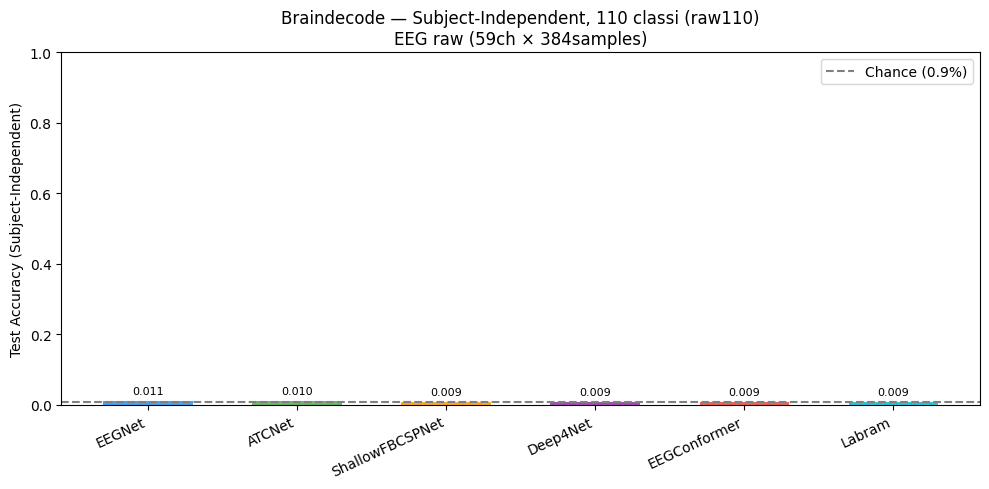

Salvato: figures/braindecode_si_raw110.png

In [11]:
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4"]

# Ordine per test_acc decrescente
df_si_sorted = df_si.sort_values("test_acc", ascending=False)
order = df_si_sorted["model"].tolist()
accs = df_si_sorted["test_acc"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(order)), accs, color=colors[:len(order)], width=0.6, alpha=0.85)
ax.axhline(chance_level, ls="--", color="gray", lw=1.5, label=f"Chance ({chance_level:.1%})")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Test Accuracy (Subject-Independent)")
ax.set_title(f"Braindecode — Subject-Independent, {N_CLASSES} classi ({_scheme})\nEEG raw (59ch × 384samples)")
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{acc:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(project_root / "figures" / f"braindecode_si_{_scheme}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: figures/braindecode_si_{_scheme}.png")